In [226]:
from kan import KAN, LBFGS, MLP
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from tqdm import tqdm
import math
import numpy as np

device = torch.device('cpu')
print(device)

cpu


In [227]:
def sol_fun(x, dim, data):
    if data=='A':
        return torch.exp(1/dim * torch.sum(torch.sin(torch.pi * x / 2) ** 2, dim=1, keepdim=True))
    elif data=='B':
        # x_safe = x.clone()
        # x_safe[x_safe == 0.0] = 1.0
        # g_x = torch.exp(-1.0 / (x_safe ** 2))
        # g_x = torch.where(x == 0.0, torch.zeros_like(x), g_x)
        # return torch.sum(g_x, dim=1, keepdim=True)
        inside_mask = (x > -1.0) & (x < 1.0)
        safe_x = torch.where(inside_mask, x, torch.zeros_like(x))
        bump = torch.exp(1.0 / (safe_x ** 2 - 1.0))
        bump_masked = torch.where(inside_mask, bump, torch.zeros_like(bump))
        return torch.sum(bump_masked, dim=1, keepdim=True)
    elif data=='C':
        return 1/math.sqrt(dim) * torch.sum(x, dim=1, keepdim=True)
    else:
        raise ValueError("Invalid data type. Choose from 'A', 'B', or 'C'.")

In [228]:
ranges = [-1, 1]
n_train = 1000
n_test = 1000
steps = 200
grids = [3, 5, 10, 20, 50]
k=3
lr=0.1
dimensions = [1000, 500, 200, 100, 50, 20, 10, 5]
# dimensions = [500, 200, 100, 50, 20, 10, 5]

In [229]:
def generate_dataset(dim, data, n_train=None, n_test=None, seed=1):
    if n_train is None:
        n_train = globals().get('n_train', 1000)
    if n_test is None:
        n_test = globals().get('n_test', 200)
    
    torch.manual_seed(seed)
    
    x_train = torch.rand((n_train, dim), device=device) * (ranges[1] - ranges[0]) + ranges[0]
    y_train = sol_fun(x_train, dim, data)
    x_test = torch.rand((n_test, dim), device=device) * (ranges[1] - ranges[0]) + ranges[0]
    y_test = sol_fun(x_test, dim, data)
    dataset = {
        'train_input': x_train,
        'train_label': y_train,
        'test_input': x_test,
        'test_label': y_test
    }
    return dataset

In [230]:
def train_kan(width, dataset, static=True, seed=1):
    
    rmses = []
    r2s = []
    if not static:
        run_steps = steps // len(grids)
    else:
        run_steps = steps

    for grid in grids:
        if grid == grids[0]:
            model = KAN(width=width, grid=grid, k=3, seed=seed, device=device, auto_save=False)
            model = model.speed()
        else:
            model.save_act = True
            model.get_act(dataset['train_input'])
            model = model.refine(grid)
            model = model.speed()
        criterion = torch.nn.MSELoss()

        optimizer = LBFGS(
                model.parameters(), 
                lr=lr, 
                history_size=10, 
                line_search_fn="strong_wolfe",
                tolerance_grad=1e-32, 
                tolerance_change=1e-32, 
                tolerance_ys=1e-32
            )
        pbar = tqdm(range(run_steps), desc='description', ncols=100)

        for _ in pbar:
            def closure():
                optimizer.zero_grad()
                loss = criterion(model(dataset['train_input']), dataset['train_label'])
                loss.backward()
                return loss

            if _ % (steps//10)== 0 and _ < steps // 2:
                model.update_grid_from_samples(dataset['train_input'])

            optimizer.step(closure)
            with torch.no_grad():
                test_pred = model(dataset['test_input'])
                mse = criterion(test_pred, dataset['test_label'])
                rmse = torch.sqrt(mse).item()
                r2 = r2_score(dataset['test_label'].cpu().numpy(), test_pred.cpu().numpy())

            pbar.set_description("rmse: %.2e | r2: %.2e " % (rmse, r2))

            rmses.append(rmse)
            r2s.append(r2)
        if static:
            break
    
    with torch.no_grad():
        final_pred = model(dataset['test_input'])
            
    results = {
        "rmses": rmses,
        "r2s": r2s,
        "preds": final_pred
    }
    return results

In [231]:
def train_mlp(width, dataset, seed=1):
    
    def r2s():
        with torch.no_grad():
            pred = mlp_model(dataset['test_input'].to(mlp_model.device))
        target = dataset['test_label'].to(mlp_model.device)
        ss_res = torch.sum((target - pred) ** 2)
        ss_tot = torch.sum((target - torch.mean(target)) ** 2)
        return 1 - (ss_res / ss_tot)
    
    torch.manual_seed(seed)
    mlp_model = MLP.MLP(width=width, act='silu', device='cpu')
    mlp_params = sum(p.numel() for p in mlp_model.parameters() if p.requires_grad)
    results = mlp_model.fit(dataset, opt="LBFGS", steps=100, lr=0.1, metrics=[r2s])
    results['param_counts'] = mlp_params

    with torch.no_grad():
        final_pred = mlp_model(dataset['test_input'].to(mlp_model.device))
    results['preds'] = final_pred
    
    return results

In [232]:
seeds = [1, 42, 123, 456, 789]
# seeds = [1, 42]


def train_all_seeds(data):
    static_kan = {}
    dyn_kan = {}
    mlp = {}

    for seed in seeds:
        
        static_kan_results = {}
        dyn_kan_results = {}
        mlp_results = {}
        
        for d in dimensions:
            dataset = generate_dataset(dim=d, seed=seed, data=data)
            width = [d, 1, 1]
            kan_param = (width[0] * width[1] * (grids[0] + k + 3) + width[1]) + (width[1] * width[2] * (grids[0] + k + 3) + width[2])
            mlp_hidden_width = (kan_param - 1) // (width[0] + 2)
            static_kan_results[d] = train_kan(width=width, dataset=dataset, static=True, seed=seed)
            dyn_kan_results[d] = train_kan(width=width, dataset=dataset, static=False, seed=seed)
            mlp_results[d] = train_mlp(width=[d, mlp_hidden_width, 1], dataset=dataset, seed=seed)
            mlp_param = mlp_results[d]['param_counts']
            print(f"Dimension {d}: KAN params: {kan_param}, MLP params: {mlp_param}")
        
        static_kan[seed] = static_kan_results
        dyn_kan[seed] = dyn_kan_results
        mlp[seed] = mlp_results
    
    torch.save(static_kan, f'static_kan_{data}.pt')
    torch.save(dyn_kan, f'dyn_{data}.pt')
    torch.save(mlp, f'mlp_{data}.pt')
    return static_kan, dyn_kan, mlp


In [ ]:
static_kan_A, dyn_kan_A, mlp_A = train_all_seeds('A')

description:   0%|                                                          | 0/200 [00:00<?, ?it/s]

rmse: 2.08e-01 | r2: -1.24e+02 :  12%|███▋                         | 25/200 [02:16<16:15,  5.57s/it]

In [ ]:
static_kan_C, dyn_kan_C, mlp_C = train_all_seeds('C')

In [ ]:
static_kan_B, dyn_kan_B, mlp_B = train_all_seeds('B')

rmse: 3.02e+01 | r2: -4.50e+01 :  55%|███████████████▉             | 55/100 [07:25<06:04,  8.10s/it]


KeyboardInterrupt: 

In [ ]:
def plot(static_kan, dyn_kan, mlp):
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 5))

    def mean_err(results_all_seeds, dimensions, seeds, key):
        means = []
        lower_errs = []
        upper_errs = []
        
        for d in dimensions:
            final_r2s = np.array([results_all_seeds[seed][d][key][-1] for seed in seeds])
            
            mean_val = np.mean(final_r2s)
            min_val = np.min(final_r2s)
            max_val = np.max(final_r2s)
            
            means.append(mean_val)
            lower_errs.append(mean_val - min_val)
            upper_errs.append(max_val - mean_val)
            
        return np.array(means), np.vstack([lower_errs, upper_errs])

    static_means_r2, static_yerr_r2 = mean_err(static_kan, dimensions, seeds, 'r2s')
    dyn_means_r2, dyn_yerr_r2 = mean_err(dyn_kan, dimensions, seeds, 'r2s')
    mlp_means_r2, mlp_yerr_r2 = mean_err(mlp, dimensions, seeds, 'r2s')
    static_means_rmse, static_yerr_rmse = mean_err(static_kan, dimensions, seeds, 'rmses')
    dyn_means_rmse, dyn_yerr_rmse = mean_err(dyn_kan, dimensions, seeds, 'rmses')
    mlp_means_rmse, mlp_yerr_rmse = mean_err(mlp, dimensions, seeds, 'test_loss')

    ax1.errorbar(dimensions, static_means_r2, yerr=static_yerr_r2, marker='s', linestyle='-', 
                capsize=4, elinewidth=1.5, alpha=0.8, label='Static KAN G=3')  
    ax1.errorbar(dimensions, dyn_means_r2, yerr=dyn_yerr_r2, marker='^', linestyle='-', 
                capsize=4, elinewidth=1.5, alpha=0.8, label='Dynamic KAN G=[3, 5, 10, 20, 50]')    
    ax1.errorbar(dimensions, mlp_means_r2, yerr=mlp_yerr_r2, marker='o', linestyle='-', 
                capsize=4, elinewidth=1.5, alpha=0.8, label='MLP')

    cutoff=4
    ax2.errorbar(dimensions[cutoff:], static_means_r2[cutoff:], yerr=static_yerr_r2[:, cutoff:], marker='s', linestyle='-',
                capsize=4, elinewidth=1.5, alpha=0.8)
    ax2.errorbar(dimensions[cutoff:], dyn_means_r2[cutoff:], yerr=dyn_yerr_r2[:, cutoff:], marker='^', linestyle='-',
                capsize=4, elinewidth=1.5, alpha=0.8)
    ax2.errorbar(dimensions[cutoff:], mlp_means_r2[cutoff:], yerr=mlp_yerr_r2[:, cutoff:], marker='^', linestyle='-',
                capsize=4, elinewidth=1.5, alpha=0.8)

    ax3.errorbar(dimensions, static_means_rmse, yerr=static_yerr_rmse, marker='s', linestyle='-',
                capsize=4, elinewidth=1.5, alpha=0.8, )   
    ax3.errorbar(dimensions, dyn_means_rmse, yerr=dyn_yerr_rmse, marker='^', linestyle='-',
                capsize=4, elinewidth=1.5, alpha=0.8)  
    ax3.errorbar(dimensions, mlp_means_rmse, yerr=mlp_yerr_rmse, marker='o', linestyle='-', label='MLP',
                capsize=4, elinewidth=1.5, alpha=0.8)

    ax1.set_xlabel('dimensions (log)')
    ax1.set_xscale('log')
    ax1.set_ylabel('R2 Score')
    ax1.axvline(x=50, color='red', linestyle='--', alpha=0.7)
    ax1.set_xticks(dimensions)
    ax1.set_xticklabels(dimensions)

    ax2.set_xlabel('dimensions (log)')
    ax2.set_xscale('log')
    ax2.set_ylabel('R2 Score')
    ax2.set_xticks(dimensions[cutoff:])
    ax2.set_xticklabels(dimensions[cutoff:])
    ax2.get_yaxis().get_major_formatter().set_useOffset(False)

    ax3.set_xlabel('dimensions (log)')
    ax3.set_xscale('log')
    ax3.set_yscale('log')
    ax3.set_ylabel('RMSE (log)')

    handles, labels = ax1.get_legend_handles_labels()

    fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=3)
    plt.suptitle('KAN vs MLP Performance with Increasing Dimensionality (Function A)')
    plt.tight_layout()
    plt.show()

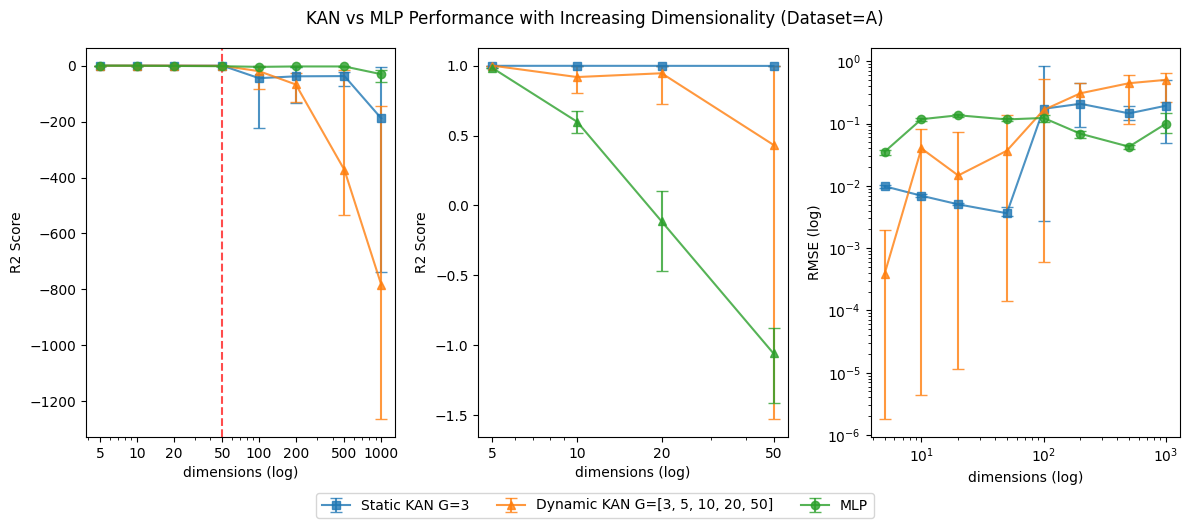

In [ ]:
plot(static_kan_A, dyn_kan_A, mlp_A)

C:\Users\runan\AppData\Local\Temp\ipykernel_38904\3656014063.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  legend = ax.legend(loc='upper right', fontsize=10, frameon=True)


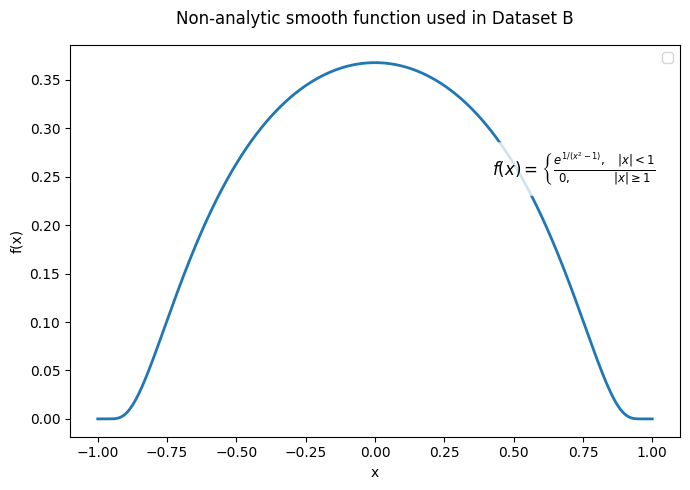

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-1, 1, 1000)
y = np.zeros_like(x)

# Apply the condition |x| < 1
mask = np.abs(x) < 1
y[mask] = np.exp(1 / (x[mask]**2 - 1))

# Initialize the plot layout (No grid lines)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(x, y, lw=2)

# Set title and axes labels
ax.set_title("Non-analytic smooth function used in Dataset B", fontsize=12, pad=15)
ax.set_xlabel("x", fontsize=10)
ax.set_ylabel("f(x)", fontsize=10)

# Create a standard clean legend frame
legend = ax.legend(loc='upper right', fontsize=10, frameon=True)

# Define the piecewise text with formatting that Matplotlib's parser handles cleanly
equation_text = (
    r"$f(x) = \left\{"
    r"\frac{"
    r"e^{1/(x^2-1)}, \quad |x| < 1"
    r"}{"
    r"0, \quad\quad\quad\ \ |x| \geq 1"
    r"}\right.$"
)

# Render the piecewise expression smoothly directly inside the plot window
# using fractional/bounding coordinates (just under the legend)
ax.text(
    0.96, 0.73, 
    equation_text, 
    transform=ax.transAxes, 
    fontsize=12, 
    horizontalalignment='right',
    verticalalignment='top',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='none', alpha=0.8)
)

# Tighten frame layout and save image file securely
plt.tight_layout()
plt.savefig("dataset_b_smooth_function.png", dpi=300)